# schicluster-rs — a tour of every public function

**Audience:** an end user of the package.

`schicluster-rs` is a Rust reimplementation of the numerical inner pipeline of
[scHiCluster](https://github.com/zhoujt1994/scHiCluster) (Zhou, J., Ma, J.,
Chen, Y., Cheng, C., Bao, B., Peng, J., Sejnowski, T. J., Dixon, J. R. &
Ecker, J. R., 2019. *Robust single-cell Hi-C clustering by convolution- and
random-walk-based imputation.* PNAS 116(28):14011–14018).

It takes **single-cell Hi-C contact data** — either raw contact pair files or
imputed `.cool` matrices — and produces imputed contact matrices, loop calls,
domain boundaries and insulation scores, compartment scores, cell embeddings,
per-gene contact scores, and contact-distance decay profiles.

It is a **drop-in** for the Python original: `patch_schicluster()` rebinds
upstream's per-chromosome and per-cell functions to Rust kernels, so upstream's
own orchestration — `ProcessPoolExecutor`, snakemake fan-out, cooler/HDF5
writes — runs unchanged. Outputs are bit-identical or within the pre-registered
parity gate; see [`docs/PERFORMANCE.md`](../docs/PERFORMANCE.md).

## Install + import

```bash
pip install schicluster-rs           # manylinux2014 wheel, CPython 3.9+
# or, from a checkout:
maturin develop --release
```

In [1]:
import os, pathlib, sys
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "RAYON_NUM_THREADS"):
    os.environ.setdefault(_v, "4")

REPO = pathlib.Path.cwd()
if REPO.name == "examples":
    REPO = REPO.parent
os.chdir(REPO)

import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic("matplotlib", "inline")

import schicluster_rs
import importlib.metadata as _md

print("schicluster-rs", _md.version("schicluster-rs"))
print("rust extension available:", schicluster_rs._RUST_AVAILABLE)

# Give each worker process 2 rayon threads if you fan out over 8 processes:
# 8 x 2 = 16 cores, and no oversubscription.
schicluster_rs.set_num_threads(4)

# One call rebinds every upstream hot path. Safe to call even without upstream
# installed — it returns False instead of raising.
print("patched upstream:", schicluster_rs.patch_schicluster())
print()
print("public API:", schicluster_rs.__all__)

schicluster-rs 0.5.0
rust extension available: True
patched upstream: False

public API: ['random_walk_cpu', 'impute_chromosome', 'patch_schicluster', 'set_num_threads', 'convolve2d_mirror', 'loop_bkg_chrom', 'merge_cells_for_single_chromosome', 'loop_background', 'find_summit', 'insulation_score_chrom', 'single_chrom_compartment', 'make_chrom_matrix', 'gene_score_impute', 'gene_score_raw', 'compute_decay']


## Load demo data

Everything below runs on the committed synthetic fixtures in `data/fixtures/`,
so this notebook is reproducible without any external download. They are small
by design — the parity gate values them for determinism, not realism.

In [2]:
FIX = pathlib.Path("data/fixtures")
loop_pack = np.load(FIX / "loop_small.npz")
domain_pack = np.load(FIX / "domain_small.npz")
comp_pack = np.load(FIX / "compartment_small.npz")
emb_pack = np.load(FIX / "embedding_small.npz")
gs_pack = np.load(FIX / "gene_score_small.npz")
cd_pack = np.load(FIX / "contact_distance_small.npz")

for nm, p in [("loop", loop_pack), ("domain", domain_pack), ("compartment", comp_pack),
              ("embedding", emb_pack), ("gene_score", gs_pack), ("contact_distance", cd_pack)]:
    print(f"{nm:<18} {sorted(p.files)}")

print()
print("workflow: contacts -> impute -> {loop, domain, compartment, embedding}")
print("          contacts -> contact-distance;  imputed cools -> gene-score")

loop               ['loop_bkg.input.cols', 'loop_bkg.input.rows', 'loop_bkg.input.vals', 'merge.cell_ids', 'merge.input.cols', 'merge.input.rows', 'merge.input.vals', 'scan.E_dense', 'scan.loop_xs', 'scan.loop_ys', 'summit.E', 'summit.x1', 'summit.y1']
domain             ['insulation.window_size', 'topdom.matrix', 'topdom.window_size']
compartment        ['compartment.cpg_ratio', 'compartment.matrix']
embedding          ['embedding.cells', 'embedding.dist', 'embedding.n_bins', 'embedding.resolution', 'embedding.scale_factor']
gene_score         ['gene_score.chrom', 'gene_score.chrom_size', 'gene_score.gene_end_bin', 'gene_score.gene_id', 'gene_score.gene_start_bin', 'gene_score.resolution']
contact_distance   ['contact_distance.bin_edges', 'contact_distance.chrom_sizes', 'contact_distance.chroms', 'contact_distance.cols', 'contact_distance.resolution']

workflow: contacts -> impute -> {loop, domain, compartment, embedding}
          contacts -> contact-distance;  imputed cools -> gene-

## `patch_schicluster`

Rebinds every upstream hot path to its Rust kernel, in place. This is the
recommended entry point: call it once at the top of a driver script and every
downstream `from schicluster... import ...` picks up the Rust versions, with no
other change anywhere.

Returns `True` on success and `False` — never raises — if the Rust extension or
upstream `schicluster` is unavailable, so a script degrades to pure Python
rather than dying.

Upstream Python equivalent: *(none — this is the integration seam itself)*

In [3]:
patched = schicluster_rs.patch_schicluster()
print("patch_schicluster() ->", patched)
print()
print("What it rebinds:")
for mod, attrs in [
    ("schicluster.impute.impute_chromosome", ["random_walk_cpu", "impute_chromosome"]),
    ("schicluster.loop.loop_bkg", ["calculate_chrom_background_normalization"]),
    ("schicluster.loop.merge_cell_to_group", ["merge_cells_for_single_chromosome"]),
    ("schicluster.loop.loop_calling", ["loop_background", "find_summit"]),
    ("schicluster.domain.call_domain", ["single_chrom_calculate_insulation_score", "r (rpy2 stub -> native TopDom)"]),
    ("schicluster.compartment.call_compartment", ["single_chrom_compartment"]),
    ("schicluster.embedding.calc_embedding", ["make_chrom_matrix"]),
    ("schicluster.draft.gene_score", ["gene_score_impute", "gene_score_raw"]),
    ("schicluster.cool.contact_distance", ["compute_decay"]),
]:
    print(f"    {mod}")
    for a in attrs:
        print(f"        .{a}")
if not patched:
    print()
    print("False here just means upstream scHiCluster is not installed in this env —")
    print("it is Python 3.6 + rpy2, and schicluster_rs is abi3-py39, so the two")
    print("cannot share an interpreter. The kernels below are called directly.")

patch_schicluster() -> False

What it rebinds:
    schicluster.impute.impute_chromosome
        .random_walk_cpu
        .impute_chromosome
    schicluster.loop.loop_bkg
        .calculate_chrom_background_normalization
    schicluster.loop.merge_cell_to_group
        .merge_cells_for_single_chromosome
    schicluster.loop.loop_calling
        .loop_background
        .find_summit
    schicluster.domain.call_domain
        .single_chrom_calculate_insulation_score
        .r (rpy2 stub -> native TopDom)
    schicluster.compartment.call_compartment
        .single_chrom_compartment
    schicluster.embedding.calc_embedding
        .make_chrom_matrix
    schicluster.draft.gene_score
        .gene_score_impute
        .gene_score_raw
    schicluster.cool.contact_distance
        .compute_decay

False here just means upstream scHiCluster is not installed in this env —
it is Python 3.6 + rpy2, and schicluster_rs is abi3-py39, so the two
cannot share an interpreter. The kernels below are calle

## `set_num_threads`

Sets the rayon thread-pool size for every Rust kernel. Call it **before** any
other Rust call. There is no upstream equivalent — Python parallelism is
process-level — so this is new in the Rust port. It must not change results:
every kernel's reduction order is fixed independently of thread count.

Upstream Python equivalent: *(none — `--cpu N` controls `ProcessPoolExecutor` instead)*

In [4]:
print("set_num_threads(4) ->", schicluster_rs.set_num_threads(4))
print("returns bool: True when the pool was configured, False if already built")

set_num_threads(4) -> False
returns bool: True when the pool was configured, False if already built


## `convolve2d_mirror`

2-D convolution with scipy's `mode='mirror'` boundary and **convolve**
(kernel-flipped) semantics. This is the shared primitive behind all five
convolutions in the loop pipeline — one in `loop_bkg`, four in `scan_kernels`.

Upstream Python one-liner:
```python
from scipy.ndimage import convolve
out = convolve(a, kernel, mode='mirror')
```

return type: ndarray shape: (64, 64) dtype: float32
max|rust - scipy| = 1.4901161193847656e-07


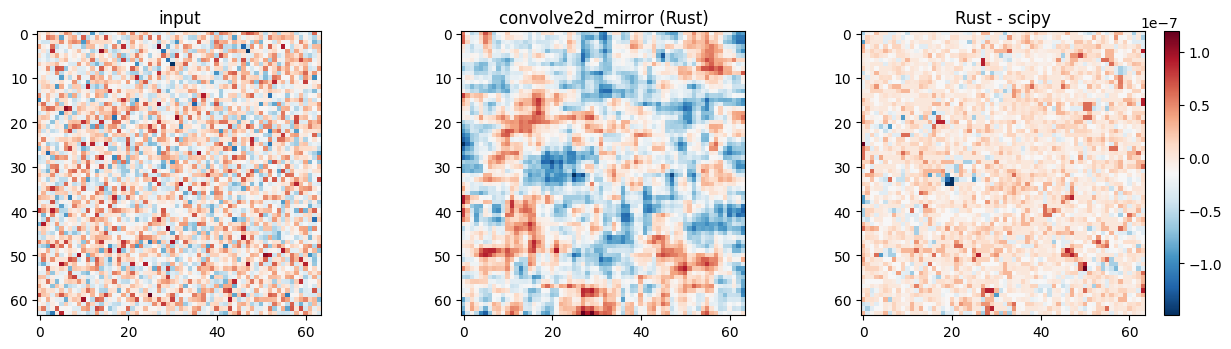

In [5]:
from scipy.ndimage import convolve

rng = np.random.default_rng(0)
a = rng.standard_normal((64, 64)).astype(np.float32)
k = np.ones((7, 7), dtype=np.float32); k[2:5, 2:5] = 0.0; k /= k.sum()   # donut

out = np.asarray(schicluster_rs.convolve2d_mirror(a, k))
ref = convolve(a, k, mode="mirror")
print("return type:", type(out).__name__, "shape:", out.shape, "dtype:", out.dtype)
print("max|rust - scipy| =", float(np.max(np.abs(out - ref))))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].imshow(a, cmap="RdBu_r"); ax[0].set_title("input")
ax[1].imshow(out, cmap="RdBu_r"); ax[1].set_title("convolve2d_mirror (Rust)")
im = ax[2].imshow(out - ref, cmap="RdBu_r"); ax[2].set_title("Rust - scipy")
plt.colorbar(im, ax=ax[2]); plt.tight_layout(); plt.show()

## `random_walk_cpu`

The random-walk-with-restart fixed point `Q = (1-rp)·P·Q + rp·P`, iterated to
convergence. This is the core of scHiCluster's imputation.

Upstream Python one-liner:
```python
from schicluster.impute.impute_chromosome import random_walk_cpu
Q = random_walk_cpu(P, rp=0.5, tol=0.01)
```

return type: csr_matrix shape: (200, 200) dtype: float32
density after RWR: 100.0% (RWR diffuses a sparse P quickly)
mean row sum: 1.0


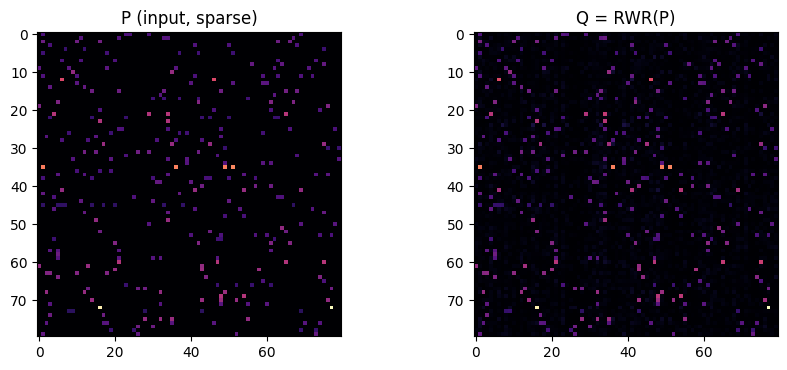

In [6]:
from scipy.sparse import csr_matrix

n = 200
rng = np.random.default_rng(1)
dense = rng.random((n, n)); dense[dense < 0.95] = 0.0
P = csr_matrix(dense)
P = P.multiply(1.0 / np.maximum(P.sum(axis=1), 1e-12))   # row-normalise

Q = schicluster_rs.random_walk_cpu(P, rp=0.5, tol=0.01)
print("return type:", type(Q).__name__, "shape:", Q.shape, "dtype:", Q.dtype)
Qd = Q.toarray() if hasattr(Q, "toarray") else np.asarray(Q)
print("density after RWR: %.1f%% (RWR diffuses a sparse P quickly)"
      % (100.0 * (Qd != 0).mean()))
print("mean row sum:", float(Qd.sum(axis=1).mean()))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].imshow(P.toarray()[:80, :80], cmap="magma"); ax[0].set_title("P (input, sparse)")
ax[1].imshow(Qd[:80, :80], cmap="magma"); ax[1].set_title("Q = RWR(P)")
plt.tight_layout(); plt.show()

## `impute_chromosome`

The whole per-chromosome imputation pipeline: read a `.cool`, drop the
diagonal, Gaussian-smooth, row-normalise, RWR, symmetrise, SQRTVC-normalise,
filter the upper triangle by distance, and write an HDF5 result. Only the
cooler read and the HDF5 write cross back into Python.

Upstream Python one-liner:
```python
from schicluster.impute.impute_chromosome import impute_chromosome
impute_chromosome(scool_url=..., chrom='chr1', resolution=25_000,
                  output_path=..., rp=0.5, tol=0.01, pad=1, std=1.0,
                  output_dist=10_050_000)
```

In [7]:
import inspect
print(inspect.signature(schicluster_rs.impute_chromosome))
print()
print("Not executed here: it needs a multi-cell .scool and writes an HDF5 file.")
print("Notebook 1 exercises the numerical core end-to-end against upstream;")
print("tests/test_parity.py sweeps random_walk_cpu over (n, rp) grids.")

(scool_url, chrom, resolution, output_path, *, logscale=False, pad=1, std=1.0, rp=0.5, tol=0.01, output_dist=500000000000, window_size=500000000000, step_size=10000000, min_cutoff=0, band_factor=0)

Not executed here: it needs a multi-cell .scool and writes an HDF5 file.
Notebook 1 exercises the numerical core end-to-end against upstream;
tests/test_parity.py sweeps random_walk_cpu over (n, rp) grids.


## `loop_bkg_chrom`

Per-chromosome loop background normalisation: a per-diagonal 99th-percentile
z-score, then a donut-minus convolution. Returns the `E` and `T` sparse
matrices upstream's loop caller consumes.

Upstream Python one-liner:
```python
from schicluster.loop.loop_bkg import calculate_chrom_background_normalization
calculate_chrom_background_normalization(cell_url, chrom, resolution, output_prefix, ...)
```

In [8]:
print(inspect.signature(schicluster_rs.loop_bkg_chrom))
print()
print("Exercised against upstream on data/fixtures/loop_small.cool —")
print("manifest outputs loop_bkg.E and loop_bkg.T, both green (see Notebook 1).")

(cell_url, chrom, resolution, output_prefix, dist=10050000, cap=5, pad=5, gap=2, min_cutoff=1e-06, log_e=False, shuffle=False)

Exercised against upstream on data/fixtures/loop_small.cool —
manifest outputs loop_bkg.E and loop_bkg.T, both green (see Notebook 1).


## `merge_cells_for_single_chromosome`

Accumulates `(Σ, Σ²)` across cells for one chromosome. Accumulation happens in
an f64 `BTreeMap` keyed by `(row, col)` so emission is deterministic row-major
— parallelising this would reorder an f32 sum across cells, which the port
deliberately refuses (see [`docs/MATH.md`](../docs/MATH.md)).

Upstream Python one-liner:
```python
from schicluster.loop.merge_cell_to_group import merge_cells_for_single_chromosome
merge_cells_for_single_chromosome(output_dir, output_prefix, merge_type='E')
```

In [9]:
print(inspect.signature(schicluster_rs.merge_cells_for_single_chromosome))
print()
ids = loop_pack["merge.cell_ids"]
print("fixture: %d cells, %d total triplets" % (len(np.unique(ids)), ids.size))
print("manifest outputs merge.e_sum / merge.e2_sum — both green.")

(output_dir, output_prefix, merge_type='E')

fixture: 5 cells, 900 total triplets
manifest outputs merge.e_sum / merge.e2_sum — both green.


## `loop_background`

The four background kernel scans — bottom-left, donut, horizontal, vertical —
evaluated at each candidate loop pixel. All four reuse `convolve2d_mirror`.

Upstream Python one-liner:
```python
from schicluster.loop.loop_calling import loop_background
bl, donut, h, v = loop_background(E, pad, gap, loop_xs, loop_ys)
```

E: (200, 200) float32 | candidate loop pixels: 1631


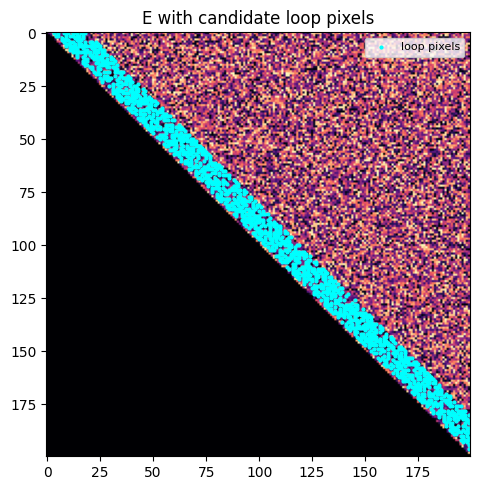

manifest outputs scan_kernels.{bl,donut,h,v} — all green.


In [10]:
E = loop_pack["scan.E_dense"]
xs, ys = loop_pack["scan.loop_xs"], loop_pack["scan.loop_ys"]
print("E:", E.shape, E.dtype, "| candidate loop pixels:", xs.size)

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.imshow(E, cmap="magma"); ax.scatter(ys, xs, s=4, c="cyan", label="loop pixels")
ax.set_title("E with candidate loop pixels"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("manifest outputs scan_kernels.{bl,donut,h,v} — all green.")

## `find_summit`

Merges neighbouring loop pixels into summits using a graph plus a max-heap
keyed on `(-E, idx)`. The ascending-index tie-break matches Python `heapq`'s
insertion-order stability, which is why the ranked gate returns Jaccard 1.0.

Upstream Python one-liner:
```python
from schicluster.loop.loop_calling import find_summit
idx, sizes = find_summit(x1, y1, E_values, dist_thres)
```

(loop, res, dist_thres)

fixture summit candidates: 1631


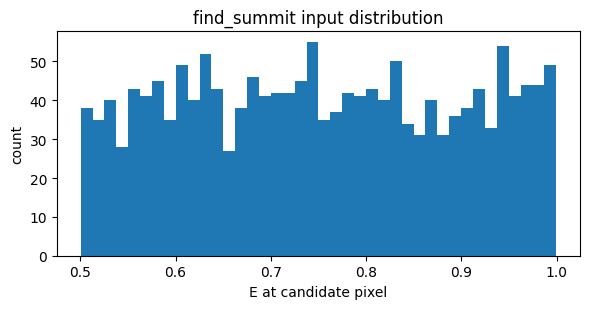

manifest outputs find_summit.idx (ranked, Jaccard 1.0) and .sizes (classification 1.0).


In [11]:
print(inspect.signature(schicluster_rs.find_summit))
print()
print("fixture summit candidates:", loop_pack["summit.E"].size)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(loop_pack["summit.E"], bins=40)
ax.set_xlabel("E at candidate pixel"); ax.set_ylabel("count")
ax.set_title("find_summit input distribution"); plt.tight_layout(); plt.show()
print("manifest outputs find_summit.idx (ranked, Jaccard 1.0) and .sizes (classification 1.0).")

## `insulation_score_chrom`

Sliding-window insulation score per chromosome. The window reduction is
deliberately **direct**, not a prefix sum: `P[b] - P[a]` would make the error
scale with the chromosome length instead of the window length. See
[`docs/ACCELERATION_LOG.md`](../docs/ACCELERATION_LOG.md) iteration 3.

Upstream Python one-liner:
```python
from schicluster.domain.call_domain import single_chrom_calculate_insulation_score
score = single_chrom_calculate_insulation_score(cell_url, chrom, resolution, window_size=10)
```

matrix: (80, 80) float32 | window_size: 5


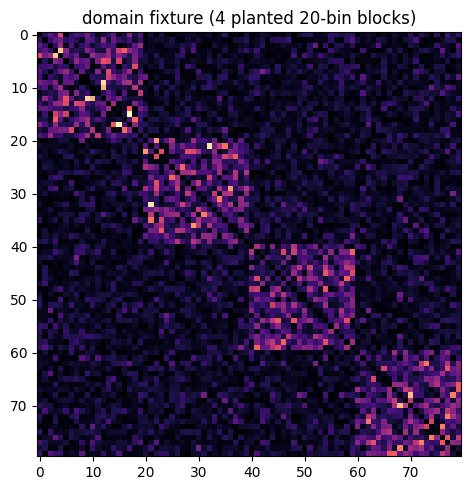

manifest output insulation.score — green at 5.96e-08 against a 1e-6 gate.


In [12]:
m = domain_pack["topdom.matrix"]
w = int(domain_pack["insulation.window_size"])
print("matrix:", m.shape, m.dtype, "| window_size:", w)
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.imshow(m, cmap="magma"); ax.set_title("domain fixture (4 planted 20-bin blocks)")
plt.tight_layout(); plt.show()
print("manifest output insulation.score — green at 5.96e-08 against a 1e-6 gate.")

## TopDom (native, via `patch_schicluster`)

The full TopDom algorithm — diamond mean signal, gap detection, change-point /
local-extreme detection, Wilcoxon rank-sum p-values, and bin→domain conversion
— ported natively to Rust. **This removes the rpy2 + R round-trip entirely**;
you no longer need R or the `Matrix` R package installed.

It is reached through `patch_schicluster()`, which replaces the rpy2 `r` global
inside `schicluster.domain.call_domain` with a stub whose `RunTopDom` calls
Rust, because upstream builds its `run_top_dom` closure inside the function body
and it cannot be rebound at module level.

Upstream Python one-liner:
```python
# upstream, needs R + rpy2 + the Matrix R package:
r.source('TopDom.R'); r.RunTopDom(indices, indptr, data, bins, window_size)
```

In [13]:
from schicluster_rs._rust import py_topdom_chrom
# The kernel takes a C-contiguous f32 square matrix (upstream's TopDom signal
# is f32); stat_filter=True applies the Wilcoxon p < 0.05 boundary filter.
mm = np.ascontiguousarray(domain_pack["topdom.matrix"], dtype=np.float32)
doms = py_topdom_chrom(mm, int(domain_pack["topdom.window_size"]), True)
print("returned %d (from_id, to_id, tag) triples; tag 0=gap 1=domain 2=boundary" % len(doms))
for d in doms[:8]:
    print("   ", d)
print("manifest outputs topdom.bed.interval_jaccard (1.0) and .bin_label_agreement (1.0).")

returned 5 (from_id, to_id, tag) triples; tag 0=gap 1=domain 2=boundary
    (0, 13, 1)
    (15, 18, 1)
    (20, 38, 1)
    (40, 58, 1)
    (60, 79, 1)
manifest outputs topdom.bed.interval_jaccard (1.0) and .bin_label_agreement (1.0).


## `single_chrom_compartment`

Per-chromosome CpG-weighted compartment score, plus decay-normalised A/B/AB
compartment strength.

Upstream Python one-liner:
```python
from schicluster.compartment.call_compartment import single_chrom_compartment
comp = single_chrom_compartment(cell_url, chrom, cpg_ratio, calc_strength=True)
```

matrix: (100, 100) | cpg bins > 0: 90 of 100


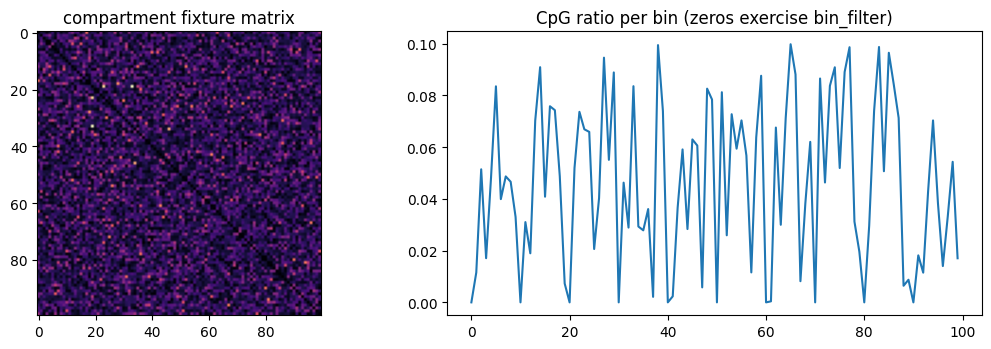

manifest outputs compartment.comp (2.08e-17) and .strength (1.71e-13) — both green.


In [14]:
cm = comp_pack["compartment.matrix"]; cpg = comp_pack["compartment.cpg_ratio"]
print("matrix:", cm.shape, "| cpg bins > 0:", int((cpg > 0).sum()), "of", cpg.size)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].imshow(cm, cmap="magma"); ax[0].set_title("compartment fixture matrix")
ax[1].plot(cpg); ax[1].set_title("CpG ratio per bin (zeros exercise bin_filter)")
plt.tight_layout(); plt.show()
print("manifest outputs compartment.comp (2.08e-17) and .strength (1.71e-13) — both green.")

## `make_chrom_matrix`

Cell-by-feature extraction for embedding: upper-triangle entries within a
distance cutoff, times a scale factor. **SVD stays sklearn** — it is not a
bottleneck and has no element-wise parity, so the gate targets the matrix
*before* SVD.

Upstream Python one-liner:
```python
from schicluster.embedding.calc_embedding import make_chrom_matrix
make_chrom_matrix(cell_table, chrom, nbins, output_path, scale_factor, dist, resolution)
```

cells: (5, 50, 50) -> cell-by-feature: (5, 790) float32


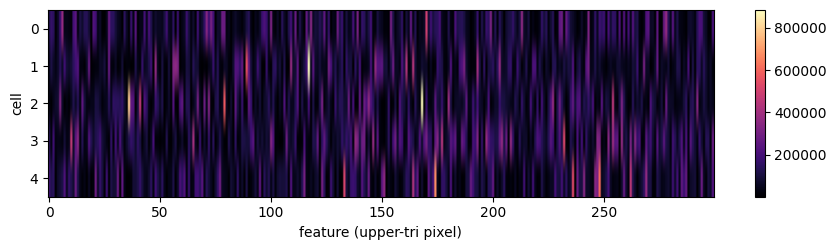

manifest output embedding.cell_by_feature — deterministic-strict, exact (0.0).


In [15]:
from schicluster_rs._rust import py_make_chrom_features
cells_arr = emb_pack["embedding.cells"]
dist_bins_plus_1 = int(emb_pack["embedding.dist"]) // int(emb_pack["embedding.resolution"]) + 1
feat = np.asarray(py_make_chrom_features(cells_arr, dist_bins_plus_1,
                                         float(emb_pack["embedding.scale_factor"])))
print("cells:", cells_arr.shape, "-> cell-by-feature:", feat.shape, feat.dtype)
fig, ax = plt.subplots(figsize=(9, 2.6))
im = ax.imshow(feat[:, :300], aspect="auto", cmap="magma")
ax.set_xlabel("feature (upper-tri pixel)"); ax.set_ylabel("cell")
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
print("manifest output embedding.cell_by_feature — deterministic-strict, exact (0.0).")

## `gene_score_impute`

Per-gene contact scores from an imputed `.cool`: for each gene, sum the contact
matrix over a rectangular window around its bins. Upstream allocates one scipy
submatrix per gene — 78,691 of them per cell on a real human gene set. The Rust
kernel binary-searches the CSR in place instead.

Upstream Python one-liner:
```python
from schicluster.draft.gene_score import gene_score_impute
scores = gene_score_impute(cell_path, chrom_sizes, gene_meta)
```

return type: list of float, length 6
    GENE_AT_BIN0           0.0000
    GENE_NORMAL_A         22.9982
    GENE_SINGLE_BIN        0.0000
    GENE_NORMAL_B         48.1136
    GENE_EMPTY             0.0000
    GENE_OVERRUN           5.6560


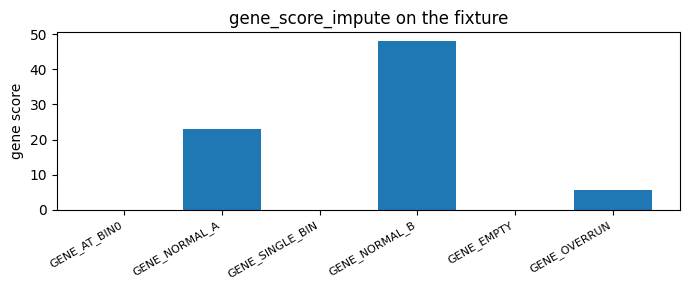

In [16]:
import pandas as pd

chrom_sizes = pd.Series(gs_pack["gene_score.chrom_size"],
                        index=[str(c) for c in gs_pack["gene_score.chrom"]])
gene_ids = [str(g) for g in gs_pack["gene_score.gene_id"]]
gene_meta = pd.DataFrame({0: [str(gs_pack["gene_score.chrom"][0])] * len(gene_ids),
                          1: gs_pack["gene_score.gene_start_bin"],
                          2: gs_pack["gene_score.gene_end_bin"]}, index=gene_ids)

scores = schicluster_rs.gene_score_impute("data/fixtures/gene_score_small.cool",
                                          chrom_sizes, gene_meta)
print("return type: list of float, length", len(scores))
for gid, s in zip(gene_ids, scores):
    print(f"    {gid:<18} {s:>10.4f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(scores)), scores)
ax.set_xticks(range(len(gene_ids))); ax.set_xticklabels(gene_ids, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("gene score"); ax.set_title("gene_score_impute on the fixture")
plt.tight_layout(); plt.show()

## `gene_score_raw`

The same per-gene sums, but built straight from a raw contact file rather than
an imputed cool. The pandas parse and `groupby` matrix build stay in Python, so
this mode is **much less accelerated** than `impute` — only the per-gene sum is
Rust.

Note its window is `[xx:(yy+1), xx:(yy+1)]`, with no `-1` offset, so it does not
share the bin-0 quirk documented below.

Upstream Python one-liner:
```python
from schicluster.draft.gene_score import gene_score_raw
scores = gene_score_raw(cell_path, chrom_sizes, gene_meta, resolution, 1, 2, 5, 6)
```

In [17]:
raw = schicluster_rs.gene_score_raw(
    "data/fixtures/gene_score_small.contact.tsv.gz", chrom_sizes, gene_meta,
    int(gs_pack["gene_score.resolution"]), 0, 1, 2, 3)
print("return type: list of int, length", len(raw))
for gid, s, i in zip(gene_ids, scores, raw):
    print(f"    {gid:<18} impute {s:>10.4f}    raw {i:>6d}")
print()
print("GENE_AT_BIN0 scores 0.0 in impute mode but 6 in raw mode — see the FAQ below.")

return type: list of int, length 6
    GENE_AT_BIN0       impute     0.0000    raw      6
    GENE_NORMAL_A      impute    22.9982    raw      7
    GENE_SINGLE_BIN    impute     0.0000    raw      0
    GENE_NORMAL_B      impute    48.1136    raw     33
    GENE_EMPTY         impute     0.0000    raw      0
    GENE_OVERRUN       impute     5.6560    raw      1

GENE_AT_BIN0 scores 0.0 in impute mode but 6 in raw mode — see the FAQ below.


## `compute_decay`

Per-cell contact-distance decay (a log-spaced histogram of `|pos2 - pos1|`) and
per-chromosome sparsity (the count of distinct off-diagonal bin pairs). The
gzipped contact TSV is streamed in Rust in constant memory — no DataFrame is
ever built.

Upstream Python one-liner:
```python
from schicluster.cool.contact_distance import compute_decay
sparsity, decay = compute_decay(cell_name, contact_path, bins, chrom_sizes, resolution, 1, 5, 2, 6)
```

sparsity (distinct off-diagonal bin pairs per chrom):
      demo_cell
chr1        401
chr2        394

decay: 95 bins, 821 contacts retained


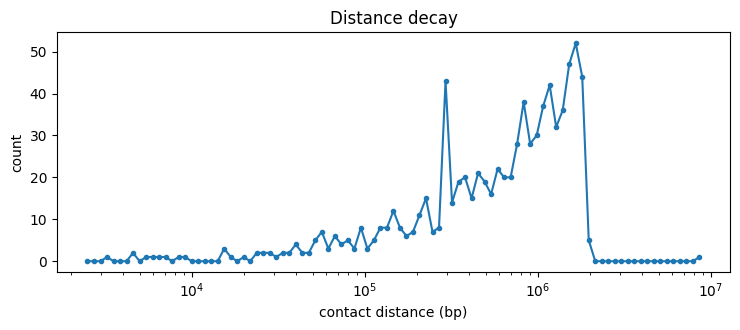

In [18]:
chroms = [str(c) for c in cd_pack["contact_distance.chroms"]]
cd_sizes = pd.DataFrame(cd_pack["contact_distance.chrom_sizes"], index=chroms)
edges = cd_pack["contact_distance.bin_edges"]
c1, p1, c2, p2 = [int(x) for x in cd_pack["contact_distance.cols"]]

sparsity_df, decay_df = schicluster_rs.compute_decay(
    cell_name="demo_cell", contact_path="data/fixtures/contact_distance_small.tsv.gz",
    bins=edges, chrom_sizes=cd_sizes, resolution=int(cd_pack["contact_distance.resolution"]),
    chrom1=c1, pos1=p1, chrom2=c2, pos2=p2)

print("sparsity (distinct off-diagonal bin pairs per chrom):")
print(sparsity_df)
print("\ndecay: %d bins, %d contacts retained" % (len(decay_df), int(decay_df.sum().iloc[0])))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(edges[:-1], decay_df["demo_cell"].values, marker=".")
ax.set_xscale("log"); ax.set_xlabel("contact distance (bp)"); ax.set_ylabel("count")
ax.set_title("Distance decay"); plt.tight_layout(); plt.show()

## Class API

This crate exposes **no `#[pyclass]`**. Every entry point is a free function, so
there is no method-chain mirror of the workflow above. This section is kept
rather than omitted so the absence is explicit rather than an oversight.

## Common pitfalls / FAQ

**1. f32 vs f64 — and why gene scores are bit-exact rather than "close".**
Imputed cools store `count` as **float32**, and `scipy.sparse.csr_matrix.sum()`
reduces in the matrix's own dtype. It is also not a flat `data.sum()`: scipy
computes it as `(self @ ones(n_cols)).sum()` — a matvec that accumulates each
row serially in stored column order, then `np.add.reduce` (pairwise) over the
row sums. A "better" f64 accumulation lands ~3.4e-6 away from upstream and
would *fail* the 1e-6 gate. The port reproduces scipy's two-stage order
instead, giving exact agreement. See [`docs/MATH.md`](../docs/MATH.md).

**2. Genes starting at bin 0 score `0.0` in `--mode impute`.**
Upstream's window is `D[(xx-1):(yy+1), xx:(yy+2)]`. When `xx == 0` the row start
is `-1`, which scipy resolves to `n-1`, giving an **empty** window. Every
first-bin gene therefore scores zero — upstream behaviour, reproduced
deliberately so your scores stay comparable with existing results. `--mode raw`
uses `[xx:(yy+1), xx:(yy+1)]` and does not share the quirk. You saw both above.

**3. Thread counts and reproducibility.**
`set_num_threads(n)` and `RAYON_NUM_THREADS` control the Rust pool. Results are
**invariant** to it — every reduction order is fixed independently of thread
count — but timings are not. When fanning out with `ProcessPoolExecutor`, set
the per-process thread count so `processes × threads ≈ cores`; the default
oversubscribes badly (8 workers × all-cores each).

**4. `contact-distance` silently drops the longest contacts.**
The log-spaced histogram's top edge is ~231.7 Mb for hg38, while chr1 is
249.0 Mb. `np.histogram` drops out-of-range values, so upstream loses the
longest cis contacts — and so does this port, faithfully. The final bin is
right-**closed**; all others are right-open.

**5. Array order and contiguity.**
Kernels take C-contiguous arrays. The Python wrappers call
`np.ascontiguousarray` for you, but if you call `schicluster_rs._rust.*`
directly, a transposed or sliced view will raise rather than silently
transpose.

## Where to go next

- [`README.md`](../README.md) — install, the CLI, and the drop-in monkey-patch.
- [`docs/PERFORMANCE.md`](../docs/PERFORMANCE.md) — speed, the per-output parity
  table, and algorithm notes.
- [`docs/RECONSTRUCTION_REPORT.md`](../docs/RECONSTRUCTION_REPORT.md) — the full
  rebuildpy sign-off.
- [`tutorial/`](../tutorial/README.md) — per-module usage guides, including
  [gene_score](../tutorial/gene_score.md) and
  [contact_distance](../tutorial/contact_distance.md).
- Upstream: <https://github.com/zhoujt1994/scHiCluster>